# Guided session: LSTM and Transformer

**Scientific question.** Given the previous 30 days of catalogue information, what is the probability of at least one M ≥ 5 event in the region during the following seven days?

One learning example is a **weekly forecast origin**. Its input is a table with 30 rows (past days) and three columns (catalogue channels). Its target is zero or one.

The session comprises **30 minutes of presentation + 30 minutes of practice**. We fit an LSTM, interpret its probability errors, and compare a Transformer on the same examples. MLP and CNN1D are extensions for independent study.

Each neural model uses **one training run, seed 7**. To examine sensitivity to initialization, continue with the [three-seed comparison](https://franplaza.github.io/courses/statsei14/tutorials/temporal-comparison.html).

**What a score means here.** Training covers 2001–2016. Validation covers 2017–2020 and also determines early stopping, so the results describe retrospective development. The catalogue is frozen and revised; historical real-time availability has not been reconstructed. The previously inspected 2021–2025 period is not evaluated and cannot serve as a new independent test.

## The 30-minute practical

Preparation A–F constructs the daily features, input windows and chronological partitions. During the guided session, we will inspect one example before fitting the models. The preparation cells provide a detailed reference for independent study. Run them before the session or open the notebook with prepared outputs.

| Session time | Practical activity |
|---|---|
| 30–34 min | Confirm setup and inspect one input window and outcome |
| 34–43 min | Fit the references; discuss LSTM settings for two minutes, then compile, fit and predict |
| 43–50 min | Interpret Brier score, log loss and validation support |
| 50–57 min | Follow the Transformer and compare the same validation origins |
| 57–60 min | Read the limits and choose an extension |

The guided session ends before the MLP/CNN1D section. Run all earlier cells in order.


## Preparation A. Load the tools

Select a Python CPU runtime in Colab. If imports are unavailable, run `%pip install tensorflow==2.19.1 keras==3.15.1 pandas scikit-learn matplotlib`, restart the runtime, and begin again. See the [environment and execution notes](https://franplaza.github.io/courses/statsei14/environment.html) for the supplied environment and verification status.

The examples use **seed 7**. Record your software versions and hardware, and note any numerical differences from the supplied results. A single run does not measure sensitivity to initialization.


In [1]:
import io
import hashlib
import zipfile
import time
from pathlib import Path
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from IPython.display import display

SEED = 7
LOOKBACK = 30
HORIZON = 7
EPOCHS = 20
BATCH_SIZE = 64

print("TensorFlow:", tf.__version__, "Keras:", keras.__version__)


TensorFlow: 2.19.1 Keras: 3.15.1


## Preparation B. Read the frozen catalogue

The data pack is pinned to a Git commit. SHA-256 checks identify the exact ZIP and catalogue, and the CSV is read into memory.

Training covers 2001–2016 and validation covers 2017–2020. The catalogue contains revised records, so this is a retrospective exercise. The previously inspected 2021–2025 period is not evaluated here.

For offline use, upload the frozen data pack as `statsei14-data-pack.zip` in the working directory before running this cell. Otherwise the cell downloads the pinned ZIP. Both paths check the same SHA-256 values.


In [2]:
PACK_URL = "https://raw.githubusercontent.com/FranPlaza/FranPlaza.github.io/0e7a7e4b1c38490018f11b26170fe6a87e4997f9/courses/statsei14/downloads/data-pack.zip"
PACK_SHA256 = "0ee5d4d71aafa19023fdb1ee6f289a11e7fd7f4ed88ad7a91032ca24505d10a2"
CATALOGUE_SHA256 = "16e9b731a5b407d75a2321d3d0d2c889542e8223a9ee4fe81efe624eb6b166d2"

local_pack = Path("statsei14-data-pack.zip")
if local_pack.exists():
    pack_bytes = local_pack.read_bytes()
    print("Data source: local frozen pack")
else:
    with urlopen(PACK_URL, timeout=60) as response:
        pack_bytes = response.read()
    print("Data source: pinned download")
assert hashlib.sha256(pack_bytes).hexdigest() == PACK_SHA256

with zipfile.ZipFile(io.BytesIO(pack_bytes)) as archive:
    csv_bytes = archive.read("data/frozen/usgs_chile_2000_2025.csv")
assert hashlib.sha256(csv_bytes).hexdigest() == CATALOGUE_SHA256

events = pd.read_csv(io.BytesIO(csv_bytes))
events["time"] = pd.to_datetime(events["time"], utc=True)
events = events.sort_values("time").reset_index(drop=True)
display(events[["time", "latitude", "longitude", "mag"]].head())


Data source: local frozen pack


,time,latitude,longitude,mag
0,2000-01-07 11:49:11.720000+00:00,-28.495,-69.196,4.0
1,2000-01-08 11:43:58.150000+00:00,-31.017,-71.339,4.4
2,2000-01-11 13:16:34.420000+00:00,-30.747,-71.319,4.5
3,2000-01-18 17:12:18.360000+00:00,-31.630,-71.451,4.9
4,2000-01-19 01:24:00.150000+00:00,-31.440,-71.384,3.8


## Preparation C. Select the region and define the daily calendar

Input events satisfy **M ≥ 4.5**. The future occurrence target uses **M ≥ 5**. We retain every calendar day, including days without events. The first year supplies history for the earliest training windows.

The three channels are log(1 + count), maximum magnitude excess above 4.5, and presence. Presence distinguishes an empty day from a day containing an event exactly at the input threshold.


In [3]:
START = pd.Timestamp("2000-01-01", tz="UTC")
END = pd.Timestamp("2026-01-01", tz="UTC")
days = pd.date_range(START, END - pd.Timedelta(days=1), freq="D")
FEATURES = ["log_count", "max_magnitude_excess", "has_event"]

inside = events["latitude"].between(-34.0, -28.0)
inside &= events["longitude"].between(-74.0, -69.0)
in_time = (events["time"] >= START) & (events["time"] < END)
selected = events.loc[inside & in_time & (events["mag"] >= 4.5)].copy()
selected["date"] = selected["time"].dt.floor("D")
print("Input events:", len(selected))


Input events: 2121


## Preparation D. Build three regional columns

Grouping counts the events on each day. Reindexing inserts the missing days. The separate target count will only be used to form outcomes after a forecast origin.


In [4]:
daily_count = selected.groupby("date").size().reindex(days, fill_value=0)
daily_count = daily_count.to_numpy(dtype="float32")

daily_maximum = selected.groupby("date")["mag"].max().reindex(days)
daily_excess = (daily_maximum - 4.5).fillna(0).to_numpy(dtype="float32")

larger_events = selected.loc[selected["mag"] >= 5.0]
target_counts = larger_events.groupby("date").size().reindex(days, fill_value=0)
target_counts = target_counts.to_numpy(dtype="float32")

daily_regional_raw = np.column_stack([
    np.log1p(daily_count),
    daily_excess,
    (daily_count > 0).astype("float32"),
]).astype("float32")
daily_table = pd.DataFrame(daily_regional_raw, index=days, columns=FEATURES)
assert daily_count.sum() == len(selected)
display(daily_table.head(10))


,log_count,max_magnitude_excess,has_event
2000-01-01 00:00:00+00:00,0.0,0.0,0.0
2000-01-02 00:00:00+00:00,0.0,0.0,0.0
2000-01-03 00:00:00+00:00,0.0,0.0,0.0
2000-01-04 00:00:00+00:00,0.0,0.0,0.0
2000-01-05 00:00:00+00:00,0.0,0.0,0.0
2000-01-06 00:00:00+00:00,0.0,0.0,0.0
2000-01-07 00:00:00+00:00,0.0,0.0,0.0
2000-01-08 00:00:00+00:00,0.0,0.0,0.0
2000-01-09 00:00:00+00:00,0.0,0.0,0.0
2000-01-10 00:00:00+00:00,0.0,0.0,0.0


## Preparation E. One Monday becomes one learning example

At origin t, take inputs from **[t − 30 days, t)** and the outcome from **[t, t + 7 days)**. The Python slices below implement those intervals directly. We omit target weeks that cross a partition boundary.

Only origins through 2020 are built. Weekly targets do not overlap, although input histories share days.


In [5]:
VAL_START = pd.Timestamp("2017-01-01", tz="UTC")
TEST_START = pd.Timestamp("2021-01-01", tz="UTC")
candidate_origins = pd.date_range("2001-01-01", "2020-12-31", freq="W-MON", tz="UTC")

histories, outcomes, kept_origins = [], [], []
for origin in candidate_origins:
    i = days.get_loc(origin)
    target_end = origin + pd.Timedelta(days=HORIZON)
    boundary = VAL_START if origin < VAL_START else TEST_START
    if i < LOOKBACK or target_end > boundary:
        continue

    history = daily_regional_raw[i - LOOKBACK:i]
    future_counts = target_counts[i:i + HORIZON]
    outcome = int(future_counts.sum() > 0)
    histories.append(history)
    outcomes.append(outcome)
    kept_origins.append(origin)

origins = pd.DatetimeIndex(kept_origins)
raw_regional = np.stack(histories)
y_regional = np.asarray(outcomes, dtype="int32")
train_mask = origins < VAL_START
val_mask = origins >= VAL_START

assert (origins[train_mask] + pd.Timedelta(days=HORIZON) <= VAL_START).all()
assert (origins[val_mask] + pd.Timedelta(days=HORIZON) <= TEST_START).all()
print("Training examples:", train_mask.sum(), "Validation examples:", val_mask.sum())
print("One input:", raw_regional[0].shape, "One outcome:", y_regional[0])


Training examples: 834 Validation examples: 208
One input: (30, 3) One outcome: 1


## Preparation F. Estimate scaling from training histories

Estimate one mean and one standard deviation per channel from the training windows. A historical day can contribute to several overlapping windows. Apply these training estimates to all validation histories. Validation has no role in estimating the scaling parameters.


In [6]:
regional_mean = raw_regional[train_mask].mean(axis=(0, 1), dtype=np.float64)
regional_scale = raw_regional[train_mask].std(axis=(0, 1), dtype=np.float64)
regional_scale = np.where(regional_scale > 0, regional_scale, 1.0)
X_regional = ((raw_regional - regional_mean) / regional_scale).astype("float32")
assert np.isfinite(X_regional).all()

display(pd.DataFrame({
    "channel": FEATURES, "training_mean": regional_mean, "training_sd": regional_scale
}))


,channel,training_mean,training_sd
0,log_count,0.125607,0.331051
1,max_magnitude_excess,0.055000,0.214342
2,has_event,0.150360,0.357424


## 1. Inspect one input before fitting a model

The array axes are **examples × days × channels**. An array row is not an individual earthquake. The raw table below shows one history before standardization; its label belongs to the following seven days.

**Discuss:** Which information remains after pooling all event locations into one regional history?


In [7]:
X_train = X_regional[train_mask]
X_val = X_regional[val_mask]
y_train = y_regional[train_mask].astype("float32")
y_val = y_regional[val_mask].astype("float32")
validation_origins = origins[val_mask]

display(pd.DataFrame({
    "partition": ["training", "validation"],
    "examples": [len(y_train), len(y_val)],
    "positive_fraction": [y_train.mean(), y_val.mean()],
}))
print("X_train:", X_train.shape, "y_train:", y_train.shape)

example = 0
history_dates = pd.date_range(origins[example] - pd.Timedelta(days=LOOKBACK), periods=LOOKBACK)
display(pd.DataFrame(raw_regional[example], index=history_dates, columns=FEATURES).tail(10))
print("Forecast origin:", origins[example], "Future weekly outcome:", y_regional[example])


,partition,examples,positive_fraction
0,training,834,0.236211
1,validation,208,0.250000


X_train: (834, 30, 3) y_train: (834,)


,log_count,max_magnitude_excess,has_event
2000-12-22 00:00:00+00:00,0.693147,0.4,1.0
2000-12-23 00:00:00+00:00,0.000000,0.0,0.0
2000-12-24 00:00:00+00:00,0.000000,0.0,0.0
2000-12-25 00:00:00+00:00,0.000000,0.0,0.0
2000-12-26 00:00:00+00:00,0.000000,0.0,0.0
2000-12-27 00:00:00+00:00,0.000000,0.0,0.0
2000-12-28 00:00:00+00:00,0.000000,0.0,0.0
2000-12-29 00:00:00+00:00,0.000000,0.0,0.0
2000-12-30 00:00:00+00:00,0.000000,0.0,0.0
2000-12-31 00:00:00+00:00,0.000000,0.0,0.0


Forecast origin: 2001-01-01 00:00:00+00:00 Future weekly outcome: 1


## 2. Fit two reference forecasts

The first forecast always returns the training positive fraction. Logistic regression uses all 90 lagged values, in the same order as the MLP below. Neither reference is tuned on validation.

Flattening preserves a fixed position for each day and channel. It does not randomly reorder the history.


In [8]:
from sklearn.linear_model import LogisticRegression

training_prevalence = float(y_train.mean())
p_prevalence = np.full(len(y_val), training_prevalence)

X_train_flat = X_train.reshape(len(X_train), LOOKBACK * len(FEATURES))
X_val_flat = X_val.reshape(len(X_val), LOOKBACK * len(FEATURES))

logistic = LogisticRegression(C=1.0, solver="lbfgs", max_iter=2000)
logistic.fit(X_train_flat, y_train)
assert logistic.n_iter_.max() < logistic.max_iter, "Inspect convergence."
p_logistic = logistic.predict_proba(X_val_flat)[:, 1]

print("Constant probability:", round(training_prevalence, 4))
print("Logistic regression input:", X_train_flat.shape)


Constant probability: 0.2362
Logistic regression input: (834, 90)


## 3. LSTM: update a learned state through the history

**Input: 30 days × 3 catalogue channels.** Each day contains log(1 + event count), maximum magnitude excess above 4.5, and an event indicator. The LSTM reads the oldest day first and the most recent day last.

The final LSTM state contains **16 learned features**. A Dense layer with a sigmoid activation transforms it into **one probability** of at least one catalogue M ≥ 5 event in the following seven days:

**30 × 3 input → final state (16 values) → Dense + sigmoid → weekly probability.**

The state starts again for each history. It is not carried between training examples or into validation.

**Discuss:** Which quantities describe observed inputs, which describe the internal representation, and which describe the model output?


In [9]:
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

inputs = keras.Input(shape=X_train.shape[1:], name="history")
history_state = keras.layers.LSTM(16, stateful=False, name="read_history")(inputs)
probability = keras.layers.Dense(1, activation="sigmoid", name="weekly_probability")(history_state)
model_lstm = keras.Model(inputs, probability, name="LSTM")
model_lstm.summary()


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ history (InputLayer)            │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ read_history (LSTM)             │ (None, 16)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ weekly_probability (Dense)      │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,297 (5.07 KB)

 Trainable params: 1,297 (5.07 KB)

 Non-trainable params: 0 (0.00 B)

### Train LSTM and obtain validation probabilities

#### Model settings and validation

The network learns weights and biases from the training data. We specify the architecture and training settings before fitting.

| Setting | Value | Meaning |
|---|---|---|
| Input history | 30 days | History available to each example |
| LSTM units | 16 | Dimension of the recurrent state |
| Adam learning rate | 0.001 | Scale of the optimizer's updates |
| Batch size | 64 windows | Training examples per update; each window contains 30 days |
| Maximum epochs | 20 | Maximum complete passes through the training examples |
| Early-stopping patience | 3 | Consecutive epochs without improved validation loss before stopping |

`compile` sets the optimizer and binary cross-entropy loss. `fit` adjusts the weights using the training examples. Early stopping monitors validation loss; `restore_best_weights=True` keeps the weights from the epoch with the lowest validation loss. `predict` applies those fitted weights to the validation histories.

Validation observations do not supply the gradient updates, but their loss influences which weights are retained. The validation scores therefore describe model development.

These values provide a **compact starting configuration for the exercise**. They have not been established as optimal by a hyperparameter search. Every neural model uses the same Adam learning rate, batch size, epoch limit and stopping rule; parameter counts differ.

The **seven-day horizon and M ≥ 5 threshold define the scientific question**. Changing them changes the target. The **seed identifies a training realization**, not a parameter to optimize for the most favourable score.

**After the session:** compare 8, 16 and 32 LSTM units with the data and remaining settings fixed, following the protocol in “Guided session complete” below.


In [10]:
model_lstm.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.BinaryCrossentropy(),
)
stopping_lstm = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

started = time.perf_counter()
history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[stopping_lstm], shuffle=False, verbose=2,
)
seconds_lstm = time.perf_counter() - started
p_lstm = model_lstm.predict(X_val, verbose=0).ravel()
print("First probabilities:", np.round(p_lstm[:5], 4))


Epoch 1/20


14/14 - 1s - 50ms/step - loss: 0.6647 - val_loss: 0.6445


Epoch 2/20


14/14 - 0s - 5ms/step - loss: 0.6275 - val_loss: 0.6056


Epoch 3/20


...

14/14 - 0s - 5ms/step - loss: 0.5341 - val_loss: 0.5477


Epoch 20/20


14/14 - 0s - 5ms/step - loss: 0.5338 - val_loss: 0.5475


First probabilities:

 [0.2111 0.1742 0.2462 0.2221 0.2103]


### Read a probability error directly

For observed outcome y and predicted probability p, the Brier error is (p − y)². The overall score is its mean. This calculation makes the quantity being compared visible.


In [11]:
squared_errors_lstm = (p_lstm.astype(float) - y_val) ** 2
brier_lstm = squared_errors_lstm.mean()
display(pd.DataFrame({
    "origin": validation_origins[:5],
    "observed": y_val[:5].astype(int),
    "probability": p_lstm[:5],
    "squared_error": squared_errors_lstm[:5],
}))
print("LSTM validation Brier:", round(float(brier_lstm), 6))


,origin,observed,probability,squared_error
0,2017-01-02 00:00:00+00:00,0,0.211066,0.044549
1,2017-01-09 00:00:00+00:00,0,0.174237,0.030359
2,2017-01-16 00:00:00+00:00,0,0.246197,0.060613
3,2017-01-23 00:00:00+00:00,0,0.222050,0.049306
4,2017-01-30 00:00:00+00:00,1,0.210282,0.623654


LSTM validation Brier: 0.181521


## 4. Evaluate the LSTM against the references

First compare probability forecasts for the **same validation weeks**. Brier score is the mean squared probability error; log loss also penalizes confident incorrect forecasts. Lower is better for both. Validation also selected the stopping epoch, so this is a development comparison.

The following calculation uses the two references and the LSTM only. You can inspect this complete comparison before introducing attention. The seed is recorded only for a neural fit.


In [12]:
probabilities_lstm = pd.DataFrame({
    "Training prevalence": p_prevalence,
    "Logistic regression": p_logistic,
    "LSTM": p_lstm,
}, index=validation_origins)

predicted_lstm = probabilities_lstm.to_numpy(dtype=float)
observed = y_val[:, None].astype(float)
assert np.isfinite(predicted_lstm).all()
assert ((predicted_lstm >= 0) & (predicted_lstm <= 1)).all()
brier_before_attention = ((predicted_lstm - observed) ** 2).mean(axis=0)
safe_lstm = np.clip(predicted_lstm, 1e-7, 1 - 1e-7)
logloss_before_attention = -(observed * np.log(safe_lstm)
    + (1 - observed) * np.log1p(-safe_lstm)).mean(axis=0)
comparison_lstm = pd.DataFrame({
    "model": probabilities_lstm.columns,
    "seed": [None, None, SEED],
    "brier": brier_before_attention,
    "log_loss": logloss_before_attention,
})
display(comparison_lstm.round(6))
print("Validation weeks:", len(y_val), "Positive fraction:", round(float(y_val.mean()), 4))


,model,seed,brier,log_loss
0,Training prevalence,NaN,0.187690,0.562855
1,Logistic regression,NaN,0.203664,0.614405
2,LSTM,7.0,0.181521,0.547512


Validation weeks: 208 Positive fraction: 0.25


## 5. Transformer: combine days through attention and position

The input and target stay fixed. Each day is first represented by 16 features. The `DayPosition` layer adds a trainable vector for each of the 30 lags, allowing the model to distinguish where an observation occurs within the input history.

The position table has shape **30 × 16**. Attention then combines information across the observed days.


In [13]:
class DayPosition(keras.layers.Layer):
    def build(self, input_shape):
        self.positions = self.add_weight(
            name="positions",
            shape=(int(input_shape[1]), int(input_shape[2])),
            initializer=keras.initializers.RandomNormal(stddev=0.02),
            trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs):
        return inputs + self.positions


### Follow the represented history through one attention block

All 30 input days precede the forecast origin. Attention across this complete input window therefore does not access the future target. Positional vectors distinguish different lags. Residual additions and normalization preserve and refine the represented history.

The final pooling and sigmoid produce the same scalar weekly probability as the other models. Attention weights by themselves would not establish a physical triggering mechanism.


In [14]:
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

inputs = keras.Input(shape=X_train.shape[1:], name="history")
projected_days = keras.layers.Dense(16, name="project_day")(inputs)
positioned_days = DayPosition(name="day_positions")(projected_days)

attention = keras.layers.MultiHeadAttention(
    num_heads=2, key_dim=8, dropout=0.0, name="attention"
)(positioned_days, positioned_days)
attended_days = keras.layers.Add(name="attention_residual")([positioned_days, attention])
attended_days = keras.layers.LayerNormalization(epsilon=1e-6, name="attention_norm")(attended_days)

feed_forward = keras.layers.Dense(16, activation="relu", name="ff_hidden")(attended_days)
feed_forward = keras.layers.Dense(16, name="ff_output")(feed_forward)
refined_days = keras.layers.Add(name="ff_residual")([attended_days, feed_forward])
refined_days = keras.layers.LayerNormalization(epsilon=1e-6, name="ff_norm")(refined_days)

history_summary = keras.layers.GlobalAveragePooling1D(name="pool_days")(refined_days)
probability = keras.layers.Dense(1, activation="sigmoid", name="weekly_probability")(history_summary)
model_transformer = keras.Model(inputs, probability, name="Transformer")
model_transformer.summary()


Model: "Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ history             │ (None, 30, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ project_day (Dense) │ (None, 30, 16)    │         64 │ history[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ day_positions       │ (None, 30, 16)    │        480 │ project_day[0][0] │
│ (DayPosition)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 30, 16)    │      1,088 │ day_positions[0]… │
│ (MultiHeadAttentio… │                   │            │ day_positions[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_residual  │ (None, 30, 16)    │          0 │ day_positions[0]… │
│ (Add)               │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_norm      │ (None, 30, 16)    │         32 │ attention_residu… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_hidden (Dense)   │ (None, 30, 16)    │        272 │ attention_norm[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_output (Dense)   │ (None, 30, 16)    │        272 │ ff_hidden[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_residual (Add)   │ (None, 30, 16)    │          0 │ attention_norm[0… │
│                     │                   │            │ ff_output[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ff_norm             │ (None, 30, 16)    │         32 │ ff_residual[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool_days           │ (None, 16)        │          0 │ ff_norm[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ weekly_probability  │ (None, 1)         │         17 │ pool_days[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,257 (8.82 KB)

 Trainable params: 2,257 (8.82 KB)

 Non-trainable params: 0 (0.00 B)

### Train Transformer and obtain validation probabilities

Train the Transformer on the same chronological examples as the LSTM, with Adam learning rate 0.001, binary cross-entropy, batches of 64 and a maximum of 20 epochs. Initialize with seed 7. Early stopping again monitors validation loss with patience 3 and restores the best weights.


In [15]:
model_transformer.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.BinaryCrossentropy(),
)
stopping_transformer = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

started = time.perf_counter()
history_transformer = model_transformer.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[stopping_transformer], shuffle=False, verbose=2,
)
seconds_transformer = time.perf_counter() - started
p_transformer = model_transformer.predict(X_val, verbose=0).ravel()
print("First probabilities:", np.round(p_transformer[:5], 4))


Epoch 1/20


14/14 - 1s - 86ms/step - loss: 0.6045 - val_loss: 0.5931


Epoch 2/20


14/14 - 0s - 5ms/step - loss: 0.5381 - val_loss: 0.5626


Epoch 3/20


...

Epoch 5/20


14/14 - 0s - 4ms/step - loss: 0.5320 - val_loss: 0.5647


Epoch 6/20


14/14 - 0s - 4ms/step - loss: 0.5316 - val_loss: 0.5661


First probabilities: [0.2969 0.2649 0.2397 0.2303 0.2337]


## 6. Compare LSTM and Transformer on the same validation weeks

Each column below contains predictions for the same validation origins. We calculate both scores directly, over rows. Log loss penalizes confident incorrect probabilities strongly. Clipping is only for the logarithms; Brier uses the original probabilities.

**Example results — seed 7.** The table reports one run per neural model, its parameter count and its actual number of epochs. Validation also determined early stopping, so these scores are development evidence. See the [environment notes](https://franplaza.github.io/courses/statsei14/environment.html) when comparing your execution with the supplied results.


In [16]:
probabilities = pd.DataFrame({
    "Training prevalence": p_prevalence,
    "Logistic regression": p_logistic,
    "LSTM": p_lstm,
    "Transformer": p_transformer,
}, index=validation_origins)

predicted = probabilities.to_numpy(dtype=float)
observed = y_val[:, None].astype(float)
assert np.isfinite(predicted).all() and ((predicted >= 0) & (predicted <= 1)).all()
squared_errors = (predicted - observed) ** 2
brier = squared_errors.mean(axis=0)

safe_probabilities = np.clip(predicted, 1e-7, 1 - 1e-7)
log_errors = -(observed * np.log(safe_probabilities)
               + (1 - observed) * np.log1p(-safe_probabilities))
logloss = log_errors.mean(axis=0)

comparison = pd.DataFrame({
    "model": probabilities.columns,
    "seed": [None, None, SEED, SEED],
    "brier": brier,
    "log_loss": logloss,
    "parameters": [1, 91, model_lstm.count_params(), model_transformer.count_params()],
    "epochs": [0, 0, len(history_lstm.history["loss"]), len(history_transformer.history["loss"])],
})
display(comparison.round(6))


,model,seed,brier,log_loss,parameters,epochs
0,Training prevalence,NaN,0.187690,0.562855,1,0
1,Logistic regression,NaN,0.203664,0.614405,91,0
2,LSTM,7.0,0.181521,0.547512,1297,20
3,Transformer,7.0,0.187901,0.562477,2257,6


## 7. Inspect learning curves

The curves show how training and validation loss changed during fitting. Predictions above use the restored best weights; the history still includes all executed epochs. The limit of 20 epochs is a maximum: early stopping can end training sooner. Reaching that limit does not establish that the training budget is adequate.

In the supplied seed-7 run, the **LSTM reaches 20 epochs**, with its lowest validation loss at epoch 20. The **Transformer stops after six epochs** and restores the weights from **epoch 3**. Validation loss therefore affects which fitted weights are used for prediction, even though validation observations do not supply gradient updates.

**Discuss:** Which epoch has the lowest validation loss for each model? Did either run reach the maximum? Did the more complex model improve on the constant reference? A single run cannot establish an architecture ranking.


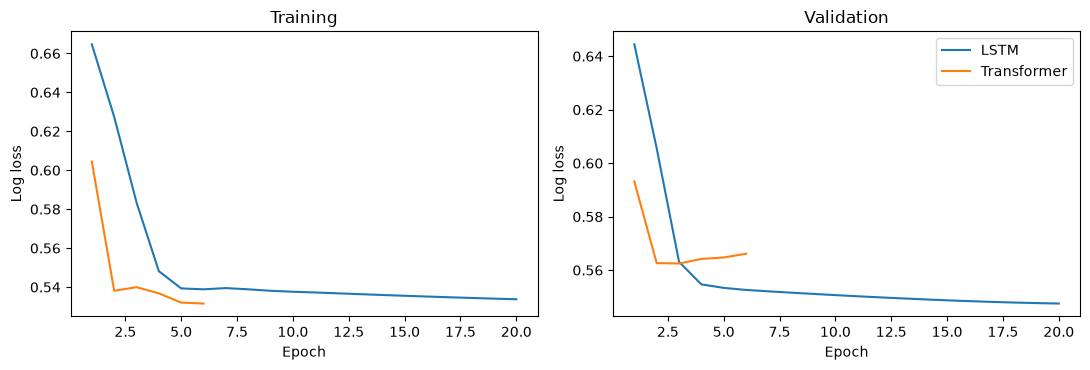

In [17]:
histories = {
    "LSTM": history_lstm, "Transformer": history_transformer,
}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for name, fitted_history in histories.items():
    epoch = np.arange(1, len(fitted_history.history["loss"]) + 1)
    axes[0].plot(epoch, fitted_history.history["loss"], label=name)
    axes[1].plot(epoch, fitted_history.history["val_loss"], label=name)
axes[0].set(title="Training", xlabel="Epoch", ylabel="Log loss")
axes[1].set(title="Validation", xlabel="Epoch", ylabel="Log loss")
axes[1].legend()
fig.tight_layout()
plt.show()


## Guided session complete

You have turned one 30 × 3 history into a probability, evaluated that probability against two references, and changed the architecture while preserving the input and outcome. This completes the 30-minute practical.

Ask: did the individual neural runs improve both scores, and what would be needed for an independent assessment? One seed does not measure initialization variability; validation is also used for early stopping. An untouched evaluation period and a predeclared protocol would be needed for a new assessment.

### Laboratory: sensitivity to recurrent-state size

1. Declare the candidates before fitting: **8, 16 and 32 LSTM units**.
2. Keep the channels, 30-day history, target, chronological partitions, scaling, optimizer, batch size and stopping rule fixed.
3. Predeclare **validation log loss as the main comparison criterion**, and report Brier score and calibration with their sample counts.
4. First inspect one run per candidate with seed 7. Then repeat every candidate with **seeds 7, 17 and 27**, retaining each run and summarizing all three seeds. Do not select the best-looking seed.
5. Examine whether any improvement with capacity is consistent under this protocol. Variation across seeds describes training sensitivity, not uncertainty from a new catalogue.

Candidate selection uses validation information, so the best validation score remains evidence for model development. A future independent assessment requires data that did not influence these choices and a protocol that respects chronological order. The already inspected **2021–2025 period is not a new independent test**.

**Other extensions:** continue with MLP/CNN1D below, [daily maps](https://franplaza.github.io/courses/statsei14/tutorials/maps.html), [the six-cell graph](https://franplaza.github.io/courses/statsei14/tutorials/graphs.html), or [sensitivity to initialization](https://franplaza.github.io/courses/statsei14/tutorials/temporal-comparison.html).


## Extension A. MLP: combine values at fixed lag positions

Flatten turns the 30 × 3 table into 90 numbers. The hidden layer learns nonlinear combinations of those values. Its weights can distinguish fixed lag positions, but the layer does not share the same detector across different days.


In [18]:
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

inputs = keras.Input(shape=X_train.shape[1:], name="history")
fixed_lags = keras.layers.Flatten(name="fixed_lag_positions")(inputs)
hidden = keras.layers.Dense(16, activation="relu", name="hidden")(fixed_lags)
probability = keras.layers.Dense(1, activation="sigmoid", name="weekly_probability")(hidden)
model_mlp = keras.Model(inputs, probability, name="MLP")
model_mlp.summary()


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ history (InputLayer)            │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fixed_lag_positions (Flatten)   │ (None, 90)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 16)             │         1,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ weekly_probability (Dense)      │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,473 (5.75 KB)

 Trainable params: 1,473 (5.75 KB)

 Non-trainable params: 0 (0.00 B)

### Train MLP and obtain validation probabilities

Train the MLP with the optimizer, loss, batch size, maximum epochs and stopping rule introduced for the LSTM. Initialize it with seed 7. Its parameter count differs, but its inputs, targets and chronological partitions are unchanged.


In [19]:
model_mlp.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.BinaryCrossentropy(),
)
stopping_mlp = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

started = time.perf_counter()
history_mlp = model_mlp.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[stopping_mlp], shuffle=False, verbose=2,
)
seconds_mlp = time.perf_counter() - started
p_mlp = model_mlp.predict(X_val, verbose=0).ravel()
print("First probabilities:", np.round(p_mlp[:5], 4))


Epoch 1/20


14/14 - 0s - 23ms/step - loss: 0.8741 - val_loss: 0.8236


Epoch 2/20


14/14 - 0s - 3ms/step - loss: 0.7797 - val_loss: 0.7609


Epoch 3/20


...

Epoch 19/20


14/14 - 0s - 3ms/step - loss: 0.4863 - val_loss: 0.5789


Epoch 20/20


14/14 - 0s - 3ms/step - loss: 0.4821 - val_loss: 0.5789


First probabilities: [0.3634 0.4025 0.3187 0.2095 0.1107]


## Extension B. CNN1D: apply shared filters to adjacent days

A filter of width three examines three neighbouring days and all input channels. The second convolution combines these local responses. Global average pooling summarizes the responses over the window.

This convolution moves over **time**, not over geographic cells. Pooling makes the final representation less sensitive to exact lag positions.

**Discuss:** What might happen if the same short pattern occurs five days earlier in the history?


In [20]:
keras.backend.clear_session()
keras.utils.set_random_seed(SEED)

inputs = keras.Input(shape=X_train.shape[1:], name="history")
local_patterns = keras.layers.Conv1D(
    16, kernel_size=3, padding="same", activation="relu", name="local_patterns"
)(inputs)
combined_patterns = keras.layers.Conv1D(
    16, kernel_size=3, padding="same", activation="relu", name="combined_patterns"
)(local_patterns)
history_summary = keras.layers.GlobalAveragePooling1D(name="pool_days")(combined_patterns)
probability = keras.layers.Dense(1, activation="sigmoid", name="weekly_probability")(history_summary)
model_cnn1d = keras.Model(inputs, probability, name="CNN1D")
model_cnn1d.summary()


Model: "CNN1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ history (InputLayer)            │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ local_patterns (Conv1D)         │ (None, 30, 16)         │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ combined_patterns (Conv1D)      │ (None, 30, 16)         │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_days                       │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ weekly_probability (Dense)      │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 961 (3.75 KB)

 Trainable params: 961 (3.75 KB)

 Non-trainable params: 0 (0.00 B)

### Train CNN1D and obtain validation probabilities

Train CNN1D on the same examples with Adam learning rate 0.001, binary cross-entropy, batches of 64 and a maximum of 20 epochs. Initialize it with seed 7 and restore the weights with the lowest validation loss using early-stopping patience 3.


In [21]:
model_cnn1d.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss=keras.losses.BinaryCrossentropy(),
)
stopping_cnn1d = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True
)

started = time.perf_counter()
history_cnn1d = model_cnn1d.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[stopping_cnn1d], shuffle=False, verbose=2,
)
seconds_cnn1d = time.perf_counter() - started
p_cnn1d = model_cnn1d.predict(X_val, verbose=0).ravel()
print("First probabilities:", np.round(p_cnn1d[:5], 4))


Epoch 1/20


14/14 - 0s - 31ms/step - loss: 0.6271 - val_loss: 0.5900


Epoch 2/20


14/14 - 0s - 4ms/step - loss: 0.5768 - val_loss: 0.5669


Epoch 3/20


...

Epoch 9/20


14/14 - 0s - 4ms/step - loss: 0.5443 - val_loss: 0.5612


Epoch 10/20


14/14 - 0s - 4ms/step - loss: 0.5437 - val_loss: 0.5613


First probabilities: [0.2602 0.2589 0.2559 0.2422 0.2541]


## Extension C. Compare all four neural architectures

Run this section after both extension models. Compare forecasts for the same validation origins, using the same score definitions. The table reports one run per neural model with seed 7; the three-seed comparison examines sensitivity to initialization separately.


In [22]:
probabilities = pd.DataFrame({
    "Training prevalence": p_prevalence,
    "Logistic regression": p_logistic,
    "MLP": p_mlp,
    "CNN1D": p_cnn1d,
    "LSTM": p_lstm,
    "Transformer": p_transformer,
}, index=validation_origins)

predicted = probabilities.to_numpy(dtype=float)
observed = y_val[:, None].astype(float)
assert np.isfinite(predicted).all() and ((predicted >= 0) & (predicted <= 1)).all()
squared_errors = (predicted - observed) ** 2
brier = squared_errors.mean(axis=0)

safe_probabilities = np.clip(predicted, 1e-7, 1 - 1e-7)
log_errors = -(observed * np.log(safe_probabilities)
               + (1 - observed) * np.log1p(-safe_probabilities))
logloss = log_errors.mean(axis=0)

comparison = pd.DataFrame({
    "model": probabilities.columns,
    "seed": [None, None, SEED, SEED, SEED, SEED],
    "brier": brier,
    "log_loss": logloss,
    "parameters": [1, 91, model_mlp.count_params(), model_cnn1d.count_params(),
                   model_lstm.count_params(), model_transformer.count_params()],
    "epochs": [0, 0, len(history_mlp.history["loss"]), len(history_cnn1d.history["loss"]),
               len(history_lstm.history["loss"]), len(history_transformer.history["loss"])],
})
display(comparison.round(6))


,model,seed,brier,log_loss,parameters,epochs
0,Training prevalence,NaN,0.187690,0.562855,1,0
1,Logistic regression,NaN,0.203664,0.614405,91,0
2,MLP,7.0,0.191811,0.578916,1473,20
3,CNN1D,7.0,0.187063,0.561202,961,10
4,LSTM,7.0,0.181521,0.547512,1297,20
5,Transformer,7.0,0.187901,0.562477,2257,6


## Optional. Inspect calibration and support

Within a probability bin, compare the average prediction with the fraction of positive weeks. Always inspect the number of weeks contributing to a point. Here we inspect the LSTM from this seed; no ensemble is constructed.

Overlapping histories and seismic sequences create dependence. The plot is descriptive and does not supply independent-bin confidence intervals.


,count,mean_probability,observed_fraction
bin,,,
"(-0.001, 0.2]",29,0.179272,0.137931
"(0.2, 0.4]",170,0.237560,0.258824
"(0.4, 0.6]",8,0.493324,0.375000
"(0.6, 0.8]",1,0.600097,1.000000


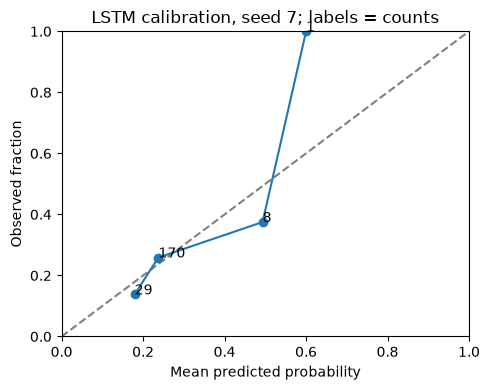

In [23]:
calibration_data = pd.DataFrame({"probability": p_lstm, "observed": y_val})
calibration_data["bin"] = pd.cut(
    calibration_data["probability"], bins=np.linspace(0, 1, 6), include_lowest=True
)
calibration = calibration_data.groupby("bin", observed=True).agg(
    count=("observed", "size"),
    mean_probability=("probability", "mean"),
    observed_fraction=("observed", "mean"),
)
display(calibration)

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot([0, 1], [0, 1], "--", color="grey")
ax.plot(calibration["mean_probability"], calibration["observed_fraction"], "o-")
for row in calibration.itertuples():
    ax.annotate(str(row.count), (row.mean_probability, row.observed_fraction))
ax.set(xlabel="Mean predicted probability", ylabel="Observed fraction",
       title=f"LSTM calibration, seed {SEED}; labels = counts", xlim=(0, 1), ylim=(0, 1))
fig.tight_layout()
plt.show()


## Optional. Save the complete single-seed run

The exported tables record the seed and are saved in `outputs_temporal`. Copy that folder before another run, because the filenames are reused. For a repeated comparison, change SEED to 17 and then 27, restart, and run the complete notebook each time. Keep every declared run and summarize the separate score tables. Do not select a favourable seed. Alternatively, use the [complete three-seed guide](https://franplaza.github.io/courses/statsei14/tutorials/temporal-comparison.html).

Changing the representation is a separate question from changing the architecture. Adding an ETAS-inspired channel belongs to that next experiment. The spatial guides retain geographic cells and estimate one probability per cell, so their numerical scores answer a different target from this regional comparison.


In [24]:
output_dir = Path("outputs_temporal")
output_dir.mkdir(exist_ok=True)
comparison.to_csv(output_dir / "validation_metrics.csv", index=False)
probabilities.assign(observed=y_val, seed=SEED).to_csv(
    output_dir / "validation_predictions.csv", index_label="origin",
)
comparison_lstm.to_csv(output_dir / "lstm_reference_metrics.csv", index=False)
print("Tables saved to:", output_dir.resolve())

protocol = pd.DataFrame([{
    "seed": SEED, "lookback_days": LOOKBACK, "horizon_days": HORIZON,
    "train_start": "2001-01-01", "train_end_exclusive": "2017-01-01",
    "validation_start": "2017-01-01", "validation_end_exclusive": "2021-01-01",
    "training_examples": int(train_mask.sum()), "validation_examples": int(val_mask.sum()),
    "maximum_epochs": EPOCHS, "batch_size": BATCH_SIZE, "early_stopping_patience": 3,
    "pack_sha256": PACK_SHA256, "catalogue_sha256": CATALOGUE_SHA256,
    "tensorflow_version": tf.__version__, "keras_version": keras.__version__,
    "historical_as_of_verified": False, "colab_execution_verified": False,
}])
protocol.to_csv(output_dir / "protocol.csv", index=False)


Tables saved to: H:\Otros ordenadores\Mi PC\1_Proyectos\2026 - Statsei 14 -\statsei14-deep-learning\qa\linear-integration-2026-10-07\executions\temporal-8809d0d176\outputs_temporal


## Sources

- [Sensitivity to initialization: temporal models, frozen data and protocol](https://franplaza.github.io/courses/statsei14/tutorials/temporal-comparison.html)
- [Keras model training API: compile, fit and predict](https://keras.io/api/models/model_training_apis/)
- [Keras EarlyStopping](https://keras.io/api/callbacks/early_stopping/)
- [Keras Functional API](https://keras.io/guides/functional_api/)
- [Keras MultiHeadAttention](https://keras.io/api/layers/attention_layers/multi_head_attention/)

Francisco Plaza-Vega · STATSEI14 · 13 October 2026
